# 🚌 DRT (Durham Region Transit) Bus Efficiency Pipeline

End-to-end notebook for analysing Durham Region Transit and building an
on-time-performance ML model.

**Data path:** this notebook stores everything under `/content/drt/` in Colab.

**Run order:**
1. Run **Setup** (installs dependencies)
2. Run **Get the GTFS data** (downloads ~7 MB from DRT)
3. Run **Build schedule index** (expands to ~9M scheduled stop-arrivals)
4. Run **Baseline analysis** (per-route diagnostics — the schedule-only answer to your question)
5. **Visualise** the results
6. *(Later, on an always-on machine)* Run the **GTFS-RT logger** to collect actual delays
7. *(After 14+ days of logging)* Run **feature engineering** and **train the model**

> ⚠️ **The logger is the gating step.** Until you run it on a Pi or VPS for at least 2 weeks, the ML model has no training data. Steps 1–5 work right now.

## 1️⃣  Setup

In [1]:
# Install dependencies (silent). Re-running is fast because pip caches.
!pip install -q gtfs-realtime-bindings pyarrow lightgbm shap requests

In [2]:
# Imports and global config
from __future__ import annotations
import os, sys, time, zipfile
from pathlib import Path
from datetime import datetime, timezone, timedelta
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd

# === EDIT THESE TWO URLs ONCE YOU PULL THEM FROM opendata.durham.ca ===
# Go to opendata.durham.ca → "GTFS-RT Vehicle Positions" → copy the .pb URL
VEHICLE_POSITIONS_URL = "https://drtonline.durhamregiontransit.com/gtfsrealtime/VehiclePositions"  # VERIFIED LIVE 2026-05-22
TRIP_UPDATES_URL      = "https://drtonline.durhamregiontransit.com/gtfsrealtime/TripUpdates"        # VERIFIED LIVE 2026-05-22

# === PATHS — auto-adapts to Colab vs local ===
IS_COLAB   = "google.colab" in sys.modules
DATA_DIR   = Path("/content/" if IS_COLAB else "./drt")
GTFS_ZIP   = DATA_DIR / "GTFS_Durham_TXT.zip"
GTFS_DIR   = DATA_DIR / "gtfs"
INDEX_DIR  = DATA_DIR / "schedule_index"
RT_LOG_DIR = DATA_DIR / "rt_log"
FEAT_DIR   = DATA_DIR / "features"
REPORT_CSV = DATA_DIR / "baseline_report.csv"
STATIC_GTFS_URL = "https://maps.durham.ca/OpenDataGTFS/GTFS_Durham_TXT.zip"
TZ = ZoneInfo("America/Toronto")

for d in (DATA_DIR, GTFS_DIR, INDEX_DIR, RT_LOG_DIR, FEAT_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Environment: {'Colab' if IS_COLAB else 'local'}")
print(f"Data root:   {DATA_DIR}")

Environment: Colab
Data root:   /content


In [3]:
# Small helper functions used throughout
def t_to_sec(t: str) -> int:
    h, m, s = map(int, t.split(":"))
    return h*3600 + m*60 + s

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dp, dl = np.radians(lat2-lat1), np.radians(lon2-lon1)
    a = np.sin(dp/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2)**2
    return 2*R*np.arcsin(np.sqrt(a))

def route_family(route_id) -> str:
    r = str(route_id)
    if r.startswith("N"): return "night"
    d = r[0] if r and r[0].isdigit() else "?"
    return {"1":"Pickering","2":"Ajax","3":"Whitby","4":"Oshawa",
            "5":"Clarington","6":"Rural","9":"PULSE/Regional"}.get(d, "other")

## 2️⃣  Get the GTFS data

Downloads the static schedule from DRT (~7 MB). Or, if you've already uploaded
`GTFS_Durham_TXT.zip` to `/content/drt/`, this cell uses that.

In [4]:
import requests
if not GTFS_ZIP.exists():
    print("Downloading static GTFS from DRT...")
    r = requests.get(STATIC_GTFS_URL, timeout=60)
    r.raise_for_status()
    GTFS_ZIP.write_bytes(r.content)
    print(f"Downloaded {len(r.content):,} bytes")
else:
    print(f"GTFS zip already at {GTFS_ZIP}")

with zipfile.ZipFile(GTFS_ZIP) as zf:
    zf.extractall(GTFS_DIR)
files = sorted(GTFS_DIR.glob("*.txt"))
print(f"\nExtracted {len(files)} files:")
for f in files:
    print(f"   {f.name}  ({f.stat().st_size:,} bytes)")

GTFS zip already at /content/GTFS_Durham_TXT.zip

Extracted 9 files:
   agency.txt  (287 bytes)
   calendar.txt  (421 bytes)
   calendar_dates.txt  (166 bytes)
   fare_attributes.txt  (96 bytes)
   routes.txt  (1,707 bytes)
   shapes.txt  (18,072,171 bytes)
   stop_times.txt  (19,969,425 bytes)
   stops.txt  (151,471 bytes)
   trips.txt  (1,223,042 bytes)


In [5]:
# Quick look at what you got
routes   = pd.read_csv(GTFS_DIR / "routes.txt")
trips    = pd.read_csv(GTFS_DIR / "trips.txt")
stops    = pd.read_csv(GTFS_DIR / "stops.txt")
calendar = pd.read_csv(GTFS_DIR / "calendar.txt")

print(f"Routes: {len(routes)}")
print(f"Stops:  {len(stops)}")
print(f"Trips:  {len(trips):,}")
print(f"Service window: {calendar['start_date'].min()} → {calendar['end_date'].max()}")
routes.head(10)

Routes: 39
Stops:  1969
Trips:  7,755
Service window: 20260317 → 20260628


,route_url,route_text_color,route_color,agency_id,route_desc,route_short_name,route_id,route_type,route_long_name
0,NaN,ffffff,006633,drt,NaN,101,101,3,Route 101
1,NaN,ffffff,006633,drt,NaN,112,112,3,Route 112
2,NaN,ffffff,006633,drt,NaN,118,118,3,Route 118
3,NaN,ffffff,006633,drt,NaN,121,121,3,Route 121
4,NaN,ffffff,006633,drt,NaN,211,211,3,Route 211
5,NaN,ffffff,006633,drt,NaN,216,216,3,Route 216
6,NaN,ffffff,006633,drt,NaN,224,224,3,Route 224
7,NaN,ffffff,006633,drt,NaN,227,227,3,Route 227
8,NaN,ffffff,006633,drt,NaN,301,301,3,Route 301
9,NaN,ffffff,006633,drt,NaN,302,302,3,Route 302


## 3️⃣  Build the schedule index

Expands `stop_times.txt × calendar` into one Parquet file per service-date,
with absolute UTC timestamps. This is what the RT log later joins against to
compute delays.

In [6]:
def _service_days(calendar, calendar_dates):
    out = {}
    dow = ["monday","tuesday","wednesday","thursday","friday","saturday","sunday"]
    for _, row in calendar.iterrows():
        sid = row["service_id"]
        start = datetime.strptime(str(row["start_date"]), "%Y%m%d").date()
        end   = datetime.strptime(str(row["end_date"]),   "%Y%m%d").date()
        days = []
        d = start
        while d <= end:
            if row[dow[d.weekday()]] == 1:
                days.append(d)
            d += timedelta(days=1)
        out[sid] = days
    for _, row in calendar_dates.iterrows():
        sid = row["service_id"]
        d = datetime.strptime(str(row["date"]), "%Y%m%d").date()
        if row["exception_type"] == 1 and sid in out and d not in out[sid]:
            out[sid].append(d)
        elif row["exception_type"] == 2 and sid in out and d in out[sid]:
            out[sid].remove(d)
    return out

def build_schedule_index():
    trips_df       = pd.read_csv(GTFS_DIR / "trips.txt")
    stop_times     = pd.read_csv(GTFS_DIR / "stop_times.txt")
    calendar_df    = pd.read_csv(GTFS_DIR / "calendar.txt")
    calendar_dates = pd.read_csv(GTFS_DIR / "calendar_dates.txt")

    stop_times["arr_sec"] = stop_times["arrival_time"].apply(t_to_sec)
    stop_times["dep_sec"] = stop_times["departure_time"].apply(t_to_sec)
    st = stop_times.merge(
        trips_df[["trip_id","service_id","route_id","direction_id","shape_id"]],
        on="trip_id", how="left",
    )
    days_map = _service_days(calendar_df, calendar_dates)
    total = 0
    for sid, day_list in days_map.items():
        subset = st[st["service_id"] == sid]
        if subset.empty or not day_list: continue
        for d in day_list:
            midnight = datetime(d.year, d.month, d.day, tzinfo=TZ)
            mid_unix = int(midnight.timestamp())
            day_df = subset.copy()
            day_df["service_date"]       = d.isoformat()
            day_df["scheduled_arr_unix"] = mid_unix + day_df["arr_sec"]
            day_df["scheduled_dep_unix"] = mid_unix + day_df["dep_sec"]
            keep = ["service_date","route_id","trip_id","stop_id","stop_sequence",
                    "direction_id","scheduled_arr_unix","scheduled_dep_unix"]
            day_df[keep].to_parquet(
                INDEX_DIR / f"date={d.isoformat()}.parquet",
                index=False, compression="snappy",
            )
            total += len(day_df)
    return total

n_rows = build_schedule_index()
n_files = len(list(INDEX_DIR.glob("*.parquet")))
print(f"Schedule index: {n_files} per-day files, {n_rows:,} scheduled stop-arrivals total")

Schedule index: 104 per-day files, 8,939,738 scheduled stop-arrivals total


## 4️⃣  Baseline analysis (schedule-only diagnostics)

Computes per-route metrics:
- **avg_speed_kmh** — commercial speed (lower = slower routes)
- **median_headway_min** — how often a bus arrives
- **headway_cov** — irregularity of scheduled spacing (lower = more regular; > 0.5 is suspect)
- **peak_trip_share** — fraction of trips in peak windows

In [7]:
def baseline_analysis():
    routes     = pd.read_csv(GTFS_DIR / "routes.txt")
    trips_df   = pd.read_csv(GTFS_DIR / "trips.txt")
    stop_times = pd.read_csv(GTFS_DIR / "stop_times.txt")
    cal        = pd.read_csv(GTFS_DIR / "calendar.txt")
    shapes     = pd.read_csv(GTFS_DIR / "shapes.txt")

    stop_times["arr_sec"] = stop_times["arrival_time"].apply(t_to_sec)

    # Compute shape distance via haversine summation (this feed has empty shape_dist_traveled)
    shapes = shapes.sort_values(["shape_id","shape_pt_sequence"]).reset_index(drop=True)
    shapes["lat2"] = shapes.groupby("shape_id")["shape_pt_lat"].shift(-1)
    shapes["lon2"] = shapes.groupby("shape_id")["shape_pt_lon"].shift(-1)
    shapes["seg_km"] = haversine_km(shapes["shape_pt_lat"], shapes["shape_pt_lon"],
                                     shapes["lat2"], shapes["lon2"])
    shape_dist = shapes.groupby("shape_id")["seg_km"].sum().rename("distance_km").reset_index()

    trip_spans = (stop_times.groupby("trip_id")
                  .agg(start_sec=("arr_sec","min"), end_sec=("arr_sec","max"),
                       n_stops=("stop_id","count")).reset_index())
    trip_spans["duration_min"] = (trip_spans["end_sec"] - trip_spans["start_sec"]) / 60
    trip_spans = trip_spans.merge(
        trips_df[["trip_id","route_id","service_id","direction_id","shape_id"]], on="trip_id"
    ).merge(shape_dist, on="shape_id", how="left")
    trip_spans["speed_kmh"] = trip_spans["distance_km"] / (trip_spans["duration_min"] / 60)

    weekday_sid = cal[(cal["monday"]==1) & (cal["friday"]==1)].iloc[0]["service_id"]
    wk = trip_spans[trip_spans["service_id"] == weekday_sid].copy()

    agg = (wk.groupby("route_id")
           .agg(weekday_trips=("trip_id","count"),
                avg_duration_min=("duration_min","mean"),
                avg_distance_km=("distance_km","mean"),
                avg_n_stops=("n_stops","mean"),
                avg_speed_kmh=("speed_kmh","mean"))
           .round(2).reset_index())
    agg["stops_per_km"]          = (agg["avg_n_stops"] / agg["avg_distance_km"]).round(2)
    agg["weekday_service_hours"] = (agg["weekday_trips"] * agg["avg_duration_min"] / 60).round(1)

    # Headway regularity
    hw_rows = []
    for r in agg["route_id"]:
        sub = wk[wk["route_id"] == r].sort_values(["direction_id","start_sec"])
        for dirn, g in sub.groupby("direction_id"):
            starts = g["start_sec"].values
            s = starts[(starts >= 6*3600) & (starts <= 21*3600)]
            if len(s) < 3: continue
            gaps = np.diff(np.sort(s)) / 60
            hw_rows.append({
                "route_id": r, "direction_id": dirn,
                "median_headway_min": float(np.median(gaps)),
                "p90_headway_min":    float(np.percentile(gaps, 90)),
                "headway_cov":        float(np.std(gaps)/np.mean(gaps)) if np.mean(gaps) > 0 else None,
            })
    hw = pd.DataFrame(hw_rows)
    if not hw.empty:
        agg = agg.merge(
            hw.groupby("route_id").agg(
                median_headway_min=("median_headway_min","mean"),
                p90_headway_min=("p90_headway_min","mean"),
                headway_cov=("headway_cov","mean"),
            ).round(2), on="route_id", how="left")

    def peak_share(r):
        sub = wk[wk["route_id"] == r]
        if sub.empty: return None
        h = sub["start_sec"] / 3600
        return round((((h>=7)&(h<10)) | ((h>=16)&(h<19))).mean(), 3)
    agg["peak_trip_share"] = agg["route_id"].map(peak_share)
    agg["region"]          = agg["route_id"].astype(str).map(route_family)
    agg = agg.sort_values("weekday_service_hours", ascending=False).reset_index(drop=True)
    agg.to_csv(REPORT_CSV, index=False)
    return agg

report = baseline_analysis()
print(f"Wrote {REPORT_CSV}")
print(f"System: {len(report)} routes, {report['weekday_trips'].sum():,} weekday trips,",
      f"median speed {report['avg_speed_kmh'].median():.1f} km/h")
report.head(10)

Wrote /content/baseline_report.csv
System: 36 routes, 2,364 weekday trips, median speed 29.0 km/h


,route_id,weekday_trips,avg_duration_min,avg_distance_km,avg_n_stops,avg_speed_kmh,stops_per_km,weekday_service_hours,median_headway_min,p90_headway_min,headway_cov,peak_trip_share,region
0,900,165,59.66,27.34,53.75,27.70,1.97,164.1,12.0,14.7,0.20,0.364,PULSE/Regional
1,920,101,73.84,38.35,59.15,31.08,1.54,124.3,20.0,22.5,0.30,0.376,PULSE/Regional
2,916,101,60.20,30.10,66.23,30.31,2.20,101.3,20.0,24.6,0.13,0.356,PULSE/Regional
3,915,106,57.03,31.29,55.53,33.27,1.77,100.8,20.0,24.0,0.14,0.330,PULSE/Regional
4,905,117,48.97,26.67,50.78,31.15,1.90,95.5,15.0,31.4,0.49,0.385,PULSE/Regional
5,901,192,29.08,10.97,25.81,23.04,2.35,93.1,8.0,17.2,0.50,0.375,PULSE/Regional
6,902,96,57.55,24.00,46.62,25.18,1.94,92.1,20.0,29.5,0.22,0.375,PULSE/Regional
7,917,80,58.50,25.29,51.06,26.21,2.02,78.0,30.0,35.9,0.14,0.275,PULSE/Regional
8,302,85,47.84,24.55,48.66,31.02,1.98,67.8,30.0,30.0,0.29,0.388,Whitby
9,921,39,80.15,45.07,32.62,33.84,0.72,52.1,20.0,20.4,2.29,0.769,PULSE/Regional


## 5️⃣  Visualise — the Oshawa picture

Each bubble is a route. **X axis** = commercial speed (km/h). **Y axis** = headway irregularity
(higher = worse). **Bubble size** = weekday service hours. Bottom-left is the danger zone:
slow buses AND irregular scheduling.

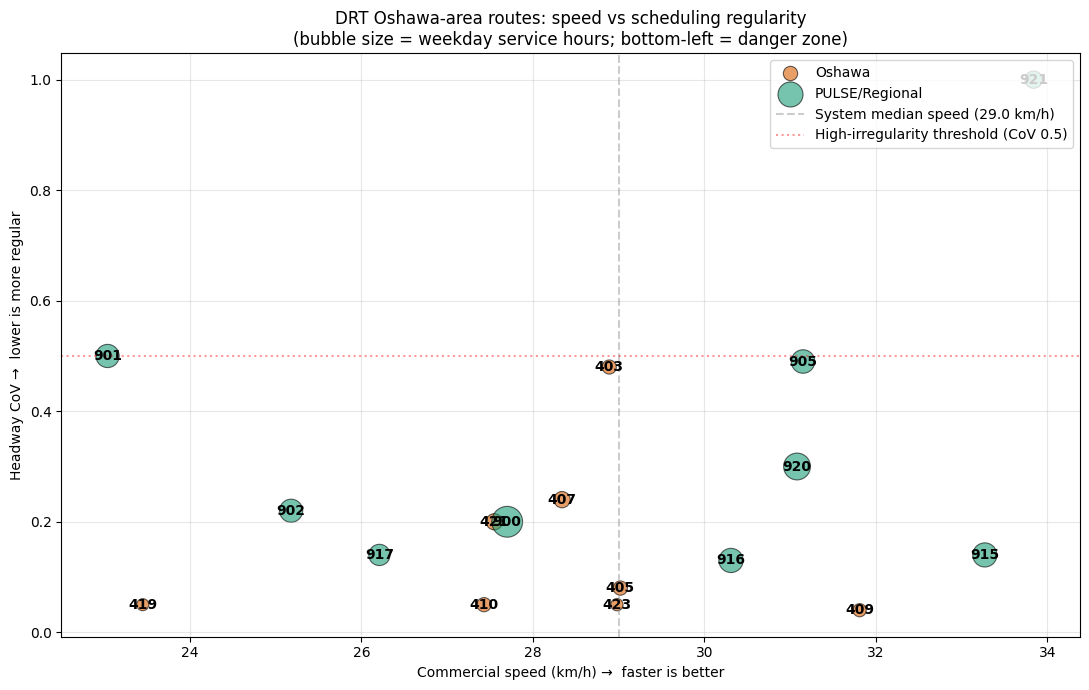

In [8]:
import matplotlib.pyplot as plt

osh = report[report["region"].isin(["Oshawa", "PULSE/Regional"])].dropna(subset=["headway_cov"]).copy()
# Clip extreme CoVs from peak-only routes (e.g. 921) so the chart stays readable
osh["headway_cov_clipped"] = osh["headway_cov"].clip(upper=1.0)

fig, ax = plt.subplots(figsize=(11, 7))
colors = {"Oshawa": "#d95f02", "PULSE/Regional": "#1b9e77"}
for region, sub in osh.groupby("region"):
    ax.scatter(sub["avg_speed_kmh"], sub["headway_cov_clipped"],
               s=sub["weekday_service_hours"]*3, alpha=0.6, c=colors[region],
               edgecolors="black", linewidth=0.8, label=region)
    for _, row in sub.iterrows():
        ax.annotate(str(row["route_id"]), (row["avg_speed_kmh"], row["headway_cov_clipped"]),
                    fontsize=10, ha="center", va="center", fontweight="bold")

ax.axvline(report["avg_speed_kmh"].median(), color="gray", linestyle="--", alpha=0.4,
           label=f"System median speed ({report['avg_speed_kmh'].median():.1f} km/h)")
ax.axhline(0.5, color="red", linestyle=":", alpha=0.4, label="High-irregularity threshold (CoV 0.5)")
ax.set_xlabel("Commercial speed (km/h) →  faster is better")
ax.set_ylabel("Headway CoV →  lower is more regular")
ax.set_title("DRT Oshawa-area routes: speed vs scheduling regularity\n"
             "(bubble size = weekday service hours; bottom-left = danger zone)")
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6️⃣  GTFS-RT logger — *the gating step for everything below*

> ⚠️ **Colab sessions die after ~12 hours.** For real multi-week collection use a
> Raspberry Pi, a free Oracle Cloud VM, or a $5 DigitalOcean droplet.
> Below is a **bounded 30-minute test run** so you can verify it works.

**The feed URLs are already filled in and were verified live on 2026-05-22.**
No edit needed — just run the cell.

In [9]:
from google.transit import gtfs_realtime_pb2
import requests

def _fetch_rt(url, timeout=15):
    try:
        r = requests.get(url, timeout=timeout); r.raise_for_status()
        m = gtfs_realtime_pb2.FeedMessage(); m.ParseFromString(r.content)
        return m
    except Exception as e:
        print(f"  fetch failed: {e}")
        return None

def _vp_to_rows(msg):
    poll_ts = datetime.now(timezone.utc).isoformat()
    rows = []
    for e in msg.entity:
        if not e.HasField("vehicle"): continue
        v = e.vehicle
        rows.append({
            "poll_ts": poll_ts, "feed_ts": msg.header.timestamp,
            "trip_id": v.trip.trip_id if v.HasField("trip") else None,
            "route_id": v.trip.route_id if v.HasField("trip") else None,
            "direction_id": v.trip.direction_id if v.HasField("trip") else None,
            "vehicle_id": v.vehicle.id if v.HasField("vehicle") else None,
            "latitude": v.position.latitude if v.HasField("position") else None,
            "longitude": v.position.longitude if v.HasField("position") else None,
            "speed": v.position.speed if v.HasField("position") else None,
            "stop_id": v.stop_id if v.HasField("stop_id") else None,
            "current_status": v.current_status if v.HasField("current_status") else None,
            "current_stop_seq": v.current_stop_sequence if v.HasField("current_stop_sequence") else None,
            "vehicle_ts": v.timestamp if v.HasField("timestamp") else None,
        })
    return rows

def _tu_to_rows(msg):
    poll_ts = datetime.now(timezone.utc).isoformat()
    rows = []
    for e in msg.entity:
        if not e.HasField("trip_update"): continue
        tu = e.trip_update
        for stu in tu.stop_time_update:
            rows.append({
                "poll_ts": poll_ts, "feed_ts": msg.header.timestamp,
                "trip_id": tu.trip.trip_id, "route_id": tu.trip.route_id,
                "vehicle_id": tu.vehicle.id if tu.HasField("vehicle") else None,
                "stop_id": stu.stop_id, "stop_sequence": stu.stop_sequence,
                "arrival_time":  stu.arrival.time  if stu.HasField("arrival")   else None,
                "arrival_delay": stu.arrival.delay if stu.HasField("arrival")   else None,
                "departure_time":  stu.departure.time  if stu.HasField("departure") else None,
                "departure_delay": stu.departure.delay if stu.HasField("departure") else None,
            })
    return rows

def _append(rows, kind):
    if not rows: return
    df = pd.DataFrame(rows)
    today = datetime.now(timezone.utc).strftime("%Y-%m-%d")
    p = RT_LOG_DIR / f"date={today}" / f"{kind}.parquet"
    p.parent.mkdir(parents=True, exist_ok=True)
    if p.exists():
        df = pd.concat([pd.read_parquet(p), df], ignore_index=True)
    df.to_parquet(p, index=False, compression="snappy")

def run_logger(interval=20, duration_min=30):
    print(f"Logging to {RT_LOG_DIR}, interval={interval}s, duration={duration_min}min")
    start = time.time()
    while True:
        vp = _fetch_rt(VEHICLE_POSITIONS_URL)
        if vp:
            rows = _vp_to_rows(vp); _append(rows, "vehicle_positions")
            print(f"[{datetime.now():%H:%M:%S}] VP: {len(rows)} vehicles")
        tu = _fetch_rt(TRIP_UPDATES_URL)
        if tu:
            rows = _tu_to_rows(tu); _append(rows, "trip_updates")
            print(f"[{datetime.now():%H:%M:%S}] TU: {len(rows)} stop-updates")
        if duration_min and (time.time() - start) > duration_min*60:
            print("done."); return
        time.sleep(interval)

# Uncomment to start a 30-minute test run AFTER editing the URLs above
# run_logger(interval=20, duration_min=30)

## 7️⃣  Feature engineering *(run after you have at least 1 day of RT log)*

Joins the schedule index with the logged actual arrivals to produce an
ML-ready table per service-date.

In [10]:
STOPPED_AT = 1  # GTFS-RT VehiclePosition.current_status enum value

def _detect_arrivals_from_vp(vp):
    if vp.empty: return pd.DataFrame()
    vp = vp.copy()
    vp["t"] = vp["vehicle_ts"].fillna(vp["feed_ts"])
    vp = vp.dropna(subset=["trip_id","stop_id","t"]).sort_values(["trip_id","vehicle_id","t"])
    at_stop = vp[vp["current_status"] == STOPPED_AT]
    arrivals = (at_stop.groupby(["trip_id","stop_id","current_stop_seq"], as_index=False)
                .agg(actual_arr_unix=("t","min"),
                     route_id=("route_id","first"),
                     vehicle_id=("vehicle_id","first"))
                .rename(columns={"current_stop_seq":"stop_sequence"}))
    arrivals["stop_sequence"] = arrivals["stop_sequence"].astype("Int64")
    return arrivals

def build_features(date_str):
    sched_path = INDEX_DIR / f"date={date_str}.parquet"
    if not sched_path.exists():
        print(f"no schedule index for {date_str}"); return 0
    sched = pd.read_parquet(sched_path)
    vp_path = RT_LOG_DIR / f"date={date_str}" / "vehicle_positions.parquet"
    if not vp_path.exists():
        print(f"no RT log for {date_str} — start the logger first"); return 0
    actuals = _detect_arrivals_from_vp(pd.read_parquet(vp_path))
    if actuals.empty: print(f"no actuals on {date_str}"); return 0

    j = sched.merge(actuals[["trip_id","stop_id","stop_sequence","actual_arr_unix","vehicle_id"]],
                    on=["trip_id","stop_id","stop_sequence"], how="inner")
    j["delay_sec"] = j["actual_arr_unix"] - j["scheduled_arr_unix"]
    j["on_time"]   = ((j["delay_sec"] >= -60) & (j["delay_sec"] <= 300)).astype(int)

    ts = pd.to_datetime(j["scheduled_arr_unix"], unit="s", utc=True).dt.tz_convert("America/Toronto")
    j["hour"], j["weekday"] = ts.dt.hour, ts.dt.weekday
    j["is_weekend"]   = (j["weekday"] >= 5).astype(int)
    j["is_peak_am"]   = ts.dt.hour.between(7, 9).astype(int)
    j["is_peak_pm"]   = ts.dt.hour.between(16, 18).astype(int)
    trip_size = j.groupby("trip_id")["stop_sequence"].transform("max")
    j["frac_of_trip"] = j["stop_sequence"] / trip_size
    j = j.sort_values(["trip_id","stop_sequence"])
    j["upstream_delay_sec"] = j.groupby("trip_id")["delay_sec"].shift(1).fillna(0)
    j["route_family"] = j["route_id"].astype(str).map(route_family)

    out = FEAT_DIR / f"date={date_str}.parquet"
    j.to_parquet(out, index=False, compression="snappy")
    print(f"{date_str}: {len(j):,} rows, OTP={j['on_time'].mean():.1%}")
    return len(j)

# Run this after the logger has produced data:
# build_features("2026-05-21")

## 8️⃣  Train the LightGBM model *(run after at least 14 days of logged data)*

Trains an on-time-performance classifier and prints feature importances.

In [11]:
def train_otp_model():
    import lightgbm as lgb
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import roc_auc_score, classification_report

    files = sorted(FEAT_DIR.glob("date=*.parquet"))
    if not files:
        print("no feature files yet — run the logger and build_features() first")
        return None
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    print(f"Training on {len(df):,} rows from {len(files)} day(s)")

    cols = ["hour","weekday","is_weekend","is_peak_am","is_peak_pm",
            "stop_sequence","frac_of_trip","upstream_delay_sec",
            "direction_id","route_family","route_id"]
    X = pd.get_dummies(df[cols], columns=["route_family","route_id"])
    y = df["on_time"]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    m = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, max_depth=8,
                            num_leaves=63, random_state=42)
    m.fit(Xtr, ytr, eval_set=[(Xte,yte)], callbacks=[lgb.early_stopping(30, verbose=False)])
    preds = m.predict_proba(Xte)[:,1]
    print(f"\nAUC: {roc_auc_score(yte, preds):.3f}")
    print(classification_report(yte, (preds>=0.5).astype(int), digits=3))

    # Top features
    imp = pd.Series(m.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("\nTop 15 features:")
    print(imp.head(15).to_string())
    return m

# model = train_otp_model()

## ✅ Next steps

1. **Get the real `.pb` URL** from `opendata.durham.ca` → "GTFS-RT Vehicle Positions"
   and paste it into the Setup cell.
2. **Deploy the logger** somewhere always-on (Pi / VPS / free Oracle Cloud VM).
   Colab is fine for testing but won't survive overnight.
3. **Wait 14+ days** for enough data to train a non-overfit model.
4. **Run `build_features("YYYY-MM-DD")`** for each logged day.
5. **Run `train_otp_model()`** — it will print AUC and feature importances.
6. **Cross-reference** the top stop-segments with Region of Durham signal locations
   to identify Transit Signal Priority candidates.

## Download all data

In [21]:
# ============================================
# VERIFY + ZIP ALL RESULTS PROPERLY
# ============================================

import os
import zipfile
from google.colab import files

# CHANGE THIS TO YOUR ACTUAL RESULTS FOLDER
RESULTS_FOLDER = "/content/"

# ZIP OUTPUT
ZIP_NAME = "/content/drt_results.zip"

# --------------------------------------------
# CHECK IF FOLDER EXISTS
# --------------------------------------------
if not os.path.exists(RESULTS_FOLDER):
    print(f"Folder not found: {RESULTS_FOLDER}")

else:
    print(f"\nScanning folder: {RESULTS_FOLDER}\n")

    total_files = 0

    # SHOW ALL FILES
    for root, dirs, files_in_dir in os.walk(RESULTS_FOLDER):
        for file in files_in_dir:
            file_path = os.path.join(root, file)
            print(file_path)
            total_files += 1

    print(f"\nTotal files found: {total_files}")

    # ----------------------------------------
    # CREATE ZIP
    # ----------------------------------------
    if total_files > 0:

        with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zipf:

            for root, dirs, files_in_dir in os.walk(RESULTS_FOLDER):

                for file in files_in_dir:

                    file_path = os.path.join(root, file)

                    # Keep relative folder structure
                    arcname = os.path.relpath(file_path, RESULTS_FOLDER)

                    zipf.write(file_path, arcname)

        print(f"\nZIP created successfully: {ZIP_NAME}")

        # CHECK ZIP SIZE
        size_mb = os.path.getsize(ZIP_NAME) / (1024 * 1024)
        print(f"ZIP Size: {size_mb:.2f} MB")

        # DOWNLOAD
        files.download(ZIP_NAME)

    else:
        print("\nNo files found inside the folder.")


Scanning folder: /content/

/content/GTFS_Durham_TXT.zip
/content/drt_data.zip
/content/baseline_report_current.csv
/content/TRNST_Bus_Boarding_Points.csv
/content/drt_results.zip
/content/baseline_report.csv
/content/gtfs-realtime-bindings-master.zip
/content/TRNST_Routes.csv
/content/.config/active_config
/content/.config/.last_opt_in_prompt.yaml
/content/.config/config_sentinel
/content/.config/default_configs.db
/content/.config/gce
/content/.config/.last_update_check.json
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/.last_survey_prompt.yaml
/content/.config/logs/2026.05.21/13.26.59.793897.log
/content/.config/logs/2026.05.21/13.26.42.337595.log
/content/.config/logs/2026.05.21/13.26.58.743083.log
/content/.config/logs/2026.05.21/13.26.27.601334.log
/content/.config/logs/2026.05.21/13.26.07.261908.log
/content/.config/logs/2026.05.21/13.26.44.509737.log
/content/.config/configurations/config_default
/content/gtfs/stop_times.txt
/

KeyboardInterrupt: 

In [17]:
from google.colab import files

# Assuming ZIP_NAME is still '/content/drt_results.zip' from the previous cell
files.download(ZIP_NAME)
print(f"Attempting to download {ZIP_NAME}. Check your browser's download panel.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Attempting to download /content/drt_results.zip. Check your browser's download panel.
